### 0. Import packages

In [1]:
import logomaker
import glob as glob
import sys, os

os.path.dirname(sys.executable)

import pandas as pd
import seaborn as sns 
import numpy as np 
import matplotlib.pyplot as plt

import sys, os, json, textwrap, itertools, requests
from pathlib import Path

from Bio.PDB import PDBParser, NeighborSearch, is_aa
from Bio.Data.IUPACData import protein_letters_3to1

import re
from typing import Optional          

from Bio.PDB import PDBParser, NeighborSearch
from scipy.spatial.distance import cdist

### 1. Exploration of structure-derived peptides

In [2]:
def aggregate_results(results_files, run_id_level=-2, extra_columns=None):
    """
    Aggregate CSV files into a single DataFrame with run identifiers.
    
    Args:
        results_files (list): List of paths to CSV files.
        run_id_level (int): Directory level to extract run ID (e.g., -2 for parent of filename).
        extra_columns (dict): Optional dictionary of column_name: lambda_function to add metadata.
    
    Returns:
        pd.DataFrame: Concatenated DataFrame with run IDs and optional columns.
    """
    if not results_files:
        print("Warning: No files provided.")
        return pd.DataFrame()

    dfs = []
    for file_path in results_files:
        # try:
        # Read CSV
        tmp = pd.read_csv(file_path)
        
        # Extract run ID from path
        run_id = os.path.split(os.path.dirname(file_path))[run_id_level]
        tmp['RUN'] = run_id
        
        # Add optional columns
        # if extra_columns:
        #     for col_name, func in extra_columns.items():
        #         tmp[col_name] = func(file_path)
        
        dfs.append(tmp)
        # print(f"Processed: {file_path}")

    # Concatenate all DataFrames
    if dfs:
        results = pd.concat(dfs, axis=0 )# , ignore_index=True)
        print(f"Aggregated {len(dfs)} files into DataFrame with {len(results)} rows.")
        return results
    else:
        print("No valid files processed.")
        return pd.DataFrame()

def grab_hla(title: str) -> Optional[str]:   # <- use Optional[str] instead of str | None
    """
    Return the first HLA allele in *title* or None.
    Handles:  HLA-A*02:01,  HLA-A02:01,  HLA-A*0201,  HLA-A0201
    """
    patterns = [
        r'(HLA-[A-Z]\*\d{2}:\d{2})',   # HLA-A*02:01
        r'(HLA-[A-Z]\d{2}:\d{2})',     # HLA-A02:01
        r'([A-Z]\*\d{4})',         # HLA-A*0201
        r'(-[A-Z]\*\d{2}:\d{2})'  ,
        r'([A-Z]\d{2}\d{2})'  ,
        r'([A-Z]\*\d{2}:\d{2})' ,
        r'(-[A-Z]\d{1}:\d{2})'  ,
        r'(-[A-Z]\d{1})'   ,
        r'(-[A-Z]\d{2})'            # HLA-A0201
    ]
    for p in patterns:
        m = re.search(p, title, flags=re.IGNORECASE)
        if m:
            return m.group(1).upper()
    return None

# Example usage for RFdiffusion results
results_dir = "/clusterfs/nilah/sergio/RFdifussion/outputs/"
results_files = glob.glob(f'{results_dir}/*/*/*.csv')

# # Define extra columns (e.g., extract contigs, iterations, num_seqs from run name)
# extra_columns = {
#     'contigs': lambda x: x.split('/')[-3].split('_C')[1].split('_I')[0],
#     'iterations': lambda x: x.split('_I')[1].split('_NS')[0],
#     'num_seqs': lambda x: x.split('_NS')[1].split('_')[0]
# }

# # Aggregate results
results = aggregate_results(results_files, run_id_level=-2) #, extra_columns=extra_columns)

# results = pd.read_csv('../data/HLAA0201_PDB_7RTD_RFdiffusion_sequences.csv')
# results['epitope'] = results['seq'].apply(lambda x: x.split("/")[1])
results['length'] = results['seq'].apply(lambda x: len(x))
results = results[results['length'] < 15]
results = results.drop_duplicates('seq')
results['epitope'] = results['seq']

Aggregated 4572 files into DataFrame with 146304 rows.


In [3]:
results.to_csv('../data/negative_ctrl_library.csv', index = False)

<Axes: >

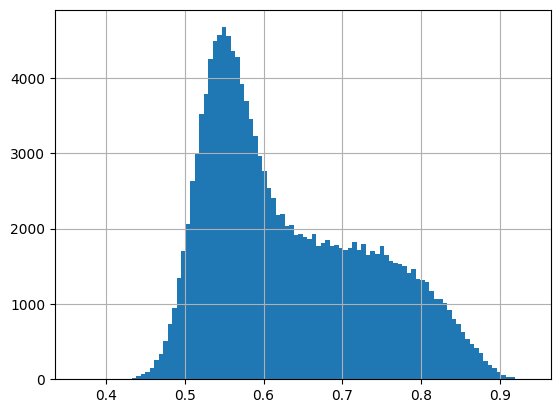

In [4]:
results['plddt'].hist(bins=100)

In [5]:
# results_meta = pd.merge(results_pdbs, df_meta, left_on='PDB', right_on='pdb_id', how='left')

results_meta = pd.read_csv('../data/rdfiffusion_output_peptides.csv.gz',compression='gzip')

results_meta['hla_allele'] = results_meta['title'].apply(grab_hla)
results_meta['hla_allele'] = results_meta['hla_allele'].str.replace('HLA','').str.replace('-','').str.replace(':','').str.replace('*','')
results_meta['epitope'] = results_meta['seq'].apply(lambda x: x.split("/")[1])
results_meta['length'] = results_meta['epitope'].apply(lambda x: len(x))
results_meta = results_meta.drop_duplicates(['pdb_id', 'epitope'])

In [6]:
AA = list("ACDEFGHIKLMNPQRSTVWY")
def build_pwm(df: pd.DataFrame,
              seq_col: str,
              allele_col: str,
              length: int = 9,
              pseudocount: int = 1):
    """
    Return {allele: (L, 20) numpy array} where rows = positions,
    columns = AA probabilities.
    Only sequences of exact 'length' are used.
    """
    pwm = {}
    for hla, grp in df[df[seq_col].str.len() == length].groupby(allele_col):
        counts = np.zeros((length, 20))
        for seq in grp[seq_col]:
            for i, aa in enumerate(seq):
                if aa in AA:
                    counts[i, AA.index(aa)] += 1
        counts += pseudocount
        pwm[hla] = counts / counts.sum(axis=1, keepdims=True)
    return pwm

In [7]:
results['hla_allele'] = 'A0201'

In [8]:
results_meta['hla_allele'].unique()

array(['B5301', 'B2705', 'B1502', None, 'N0101', 'B5703', 'B8', 'A0201',
       'B1801', 'B3501', 'A2402', 'B4403', 'B3508', 'B1301', 'A2',
       'B4405', 'B5801', 'B3505', 'B1501', 'A6', 'A0206', 'A0207',
       'B4001', 'B5803', 'B5701', 'C1203', 'C1202', 'B2706', 'B3503'],
      dtype=object)

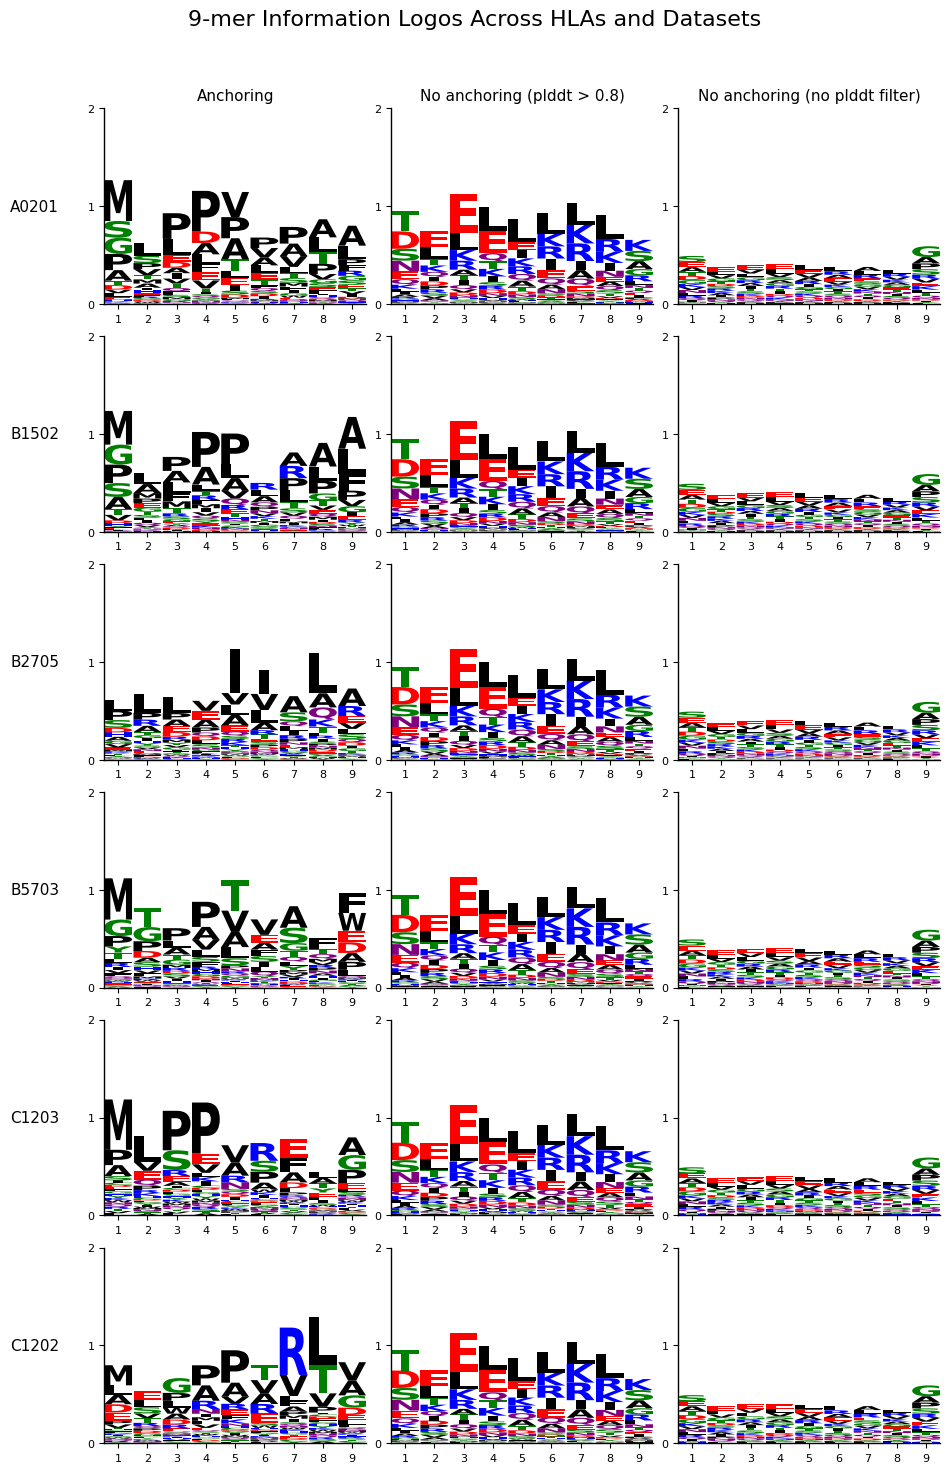

In [9]:

amino_acids = list("ACDEFGHIKLMNPQRSTVWY")
bg_probs = [1 / 20] * 20
alleles =  ['A0201','B1502', 'B2705', 'B5703', 'C1203', 'C1202'] #results_meta[results_meta['hla_allele'].notna()]['hla_allele'].unique()
datasets_names = ["Anchoring", "No anchoring (plddt > 0.8)", "No anchoring (no plddt filter)"]

n_rows = len(alleles)
n_cols = len(datasets_names)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.2, n_rows * 2.4), squeeze=False)

for row_idx, allele in enumerate(alleles):

    pwm_pred     = build_pwm(results_meta[(results_meta['plddt'] > 0.5) & (results_meta['hla_allele'] == allele)],
                            seq_col="epitope",  allele_col="hla_allele")
    
    results['hla_allele'] = allele

    pwm_train     = build_pwm(results[(results['plddt'] > 0.8)],
                        seq_col="seq",  allele_col="hla_allele")

    pwm_train2     = build_pwm(results,
                        seq_col="seq",  allele_col="hla_allele")

    datasets = {
        "Anchoring": pwm_pred,
        "No anchoring (plddt > 0.8)": pwm_train,
        "No anchoring (no plddt filter)": pwm_train2
    }

    common_hlas = sorted(set.intersection(*(set(d) for d in datasets.values())))
    if not common_hlas:
        continue

    hla = common_hlas[0]  # pick one if only one per allele anyway

    for col_idx, (dataset_name, pwm_dict) in enumerate(datasets.items()):
        ax = axes[row_idx][col_idx]
        pwm = pwm_dict[hla]
        freq_df = pd.DataFrame(pwm, columns=amino_acids)
        info_df = logomaker.transform_matrix(freq_df, from_type="probability", to_type="information", background=bg_probs)

        logo = logomaker.Logo(info_df, ax=ax, color_scheme="chemistry")
        logo.style_spines(visible=False)
        logo.style_spines(spines=['left', 'bottom'], visible=True)

        ax.set_xticks(range(pwm.shape[0]))
        ax.set_xticklabels([str(i + 1) for i in range(pwm.shape[0])], fontsize=8)
        ax.set_yticks([0, 1, 2])
        ax.set_yticklabels(["0", "1", "2"], fontsize=8)
        ax.set_ylabel("")

        if row_idx == 0:
            ax.set_title(dataset_name, fontsize=11, pad=6)
        if col_idx == 0:
            ax.set_ylabel(allele, rotation=0, fontsize=11, labelpad=38, va="center")

plt.suptitle("9-mer Information Logos Across HLAs and Datasets", fontsize=16, y=1.02)
plt.tight_layout(h_pad=0.6, w_pad=0.6)

In [52]:
from scipy.stats import gaussian_kde
from matplotlib.patches import Rectangle
from matplotlib.ticker import PercentFormatter
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

def plot_kde_density(
    df,
    pos2_set={"M", "L", "T"},
    last_set={"V", "L", "T", "A"},
    alleles=('A0201', 'A0206', 'A0207'),
    match_types=("pos2_match", "last_match", "either_match", "both_match"),
    x_candidates=("rmsd", "i_ptm", "_iptm", "mpnn"),
    y_col="plddt",
    show_grey=True,
    show_window=True,
    thr=0.80,
    save_dir="../figures",
    fname_prefix="kde_density",
    # -------- new controls --------
    figure_title=None,            # override the auto suptitle if provided
    suptitle_size=18,             # size of the main title (suptitle)
    panel_title_size=13,          # size of per-panel titles
    axis_label_size=12,           # size of x/y axis labels
    tick_label_size=10,           # size of tick labels
    legend_size=10,               # size of legend and colorbar label
    annotation_size=10            # size of in-plot annotations
):
    """
    KDE density scatter for peptide quality vs confidence, split by anchor-match logic.

    Returns:
        pandas.DataFrame with per-panel counts (N_in window, totals, fractions).
    """

    # ---------- style: journal-ready ----------
    mpl.rcParams.update({
        "figure.dpi": 180,
        "savefig.dpi": 300,
        "axes.titlesize": panel_title_size,
        "axes.labelsize": axis_label_size,
        "xtick.labelsize": tick_label_size,
        "ytick.labelsize": tick_label_size,
        "legend.fontsize": legend_size,
        "font.family": "DejaVu Sans",
    })
    sns.set_theme(context="paper", style="whitegrid")

    # ---------- nice labels for columns ----------
    label_map = {
        "rmsd": "Backbone RMSD (Å)",
        "i_ptm": "Interface pTM score",
        "_iptm": "Interface pTM score",
        "mpnn": "ProteinMPNN sequence score",
        "plddt": "AlphaFold pLDDT",
    }

    # pick the first available x column
    x_col = next((c for c in x_candidates if c in df.columns), None)
    if x_col is None:
        raise ValueError(f"No x-column found. Tried: {x_candidates}")

    # enforce required columns
    needed = {x_col, y_col, "epitope", "hla_allele"}
    missing = sorted(list(needed - set(df.columns)))
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    # subset to alleles if provided
    sub = df[[x_col, y_col, "epitope", "hla_allele"]].copy()
    if alleles is not None:
        sub = sub[sub["hla_allele"].isin(alleles)]
    sub = sub.dropna()

    # class annotations
    s = sub["epitope"].astype(str).str.upper()
    sub["pos2_match"]   = s.str.len().ge(2) & s.str[1].isin(pos2_set)
    sub["last_match"]   = s.str.len().ge(1) & s.str[-1].isin(last_set)
    sub["either_match"] = sub["pos2_match"] | sub["last_match"]
    sub["both_match"]   = sub["pos2_match"] & sub["last_match"]

    valid_matches = {"pos2_match", "last_match", "either_match", "both_match"}
    match_types = [m for m in match_types if m in valid_matches]
    if not match_types:
        raise ValueError(f"No valid match types provided. Valid options: {sorted(valid_matches)}")

    # helper: KDE density
    def point_density(x, y):
        x = np.asarray(x, float)
        y = np.asarray(y, float)
        if len(x) < 5:
            return np.zeros_like(x)
        kde = gaussian_kde(np.vstack([x, y]))
        return kde(np.vstack([x, y]))

    # helper: annotate high-confidence quadrant
    def annotate_window(ax, data, x_col, y_col, thr):
        if not show_window:
            return None, len(data), None

        ax.axvline(thr, ls="--", lw=1, color="gray", alpha=0.9, zorder=1)
        ax.axhline(thr, ls="--", lw=1, color="gray", alpha=0.9, zorder=1)
        ax.add_patch(Rectangle((thr, thr), 1 - thr, 1 - thr,
                               facecolor="gray", alpha=0.08, zorder=0))
        ax.text(thr + 0.01, thr + 0.01, "High-confidence quadrant",
                fontsize=annotation_size, color="gray", va="bottom", ha="left")

        n_total = len(data)
        mask_in = (data[x_col] >= thr) & (data[y_col] >= thr)
        n_in = int(mask_in.sum())
        frac = n_in / n_total if n_total else np.nan

        ax.text(0.01, 0.99,
                f"N in quadrant (≥{thr}, ≥{thr}) = {n_in:,}/{n_total:,} ({frac:.1%})",
                transform=ax.transAxes, ha="left", va="top",
                fontsize=annotation_size,
                bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.8", alpha=0.95))
        return n_in, n_total, frac

    # panel title helpers
    panel_title = {
        "pos2_match":   "Position 2 anchor match",
        "last_match":   "C-terminus anchor match",
        "either_match": "Either anchor match",
        "both_match":   "Both anchors match",
    }
    side_title = {False: "No", True: "Both"}

    # set sensible axis ranges if scores are on [0,1]
    def score_bounds(col, name):
        if col in ("plddt", "i_ptm", "_iptm", "mpnn"):
            return (0.0, 1.0)
        if name == label_map.get("rmsd", "") or col == "rmsd":
            return None
        return None

    # collect counts
    all_counts = []

    for group_col in match_types:
        g_false = sub[sub[group_col] == False].copy()
        g_true  = sub[sub[group_col] == True].copy()

        g_false["density"] = point_density(g_false[x_col], g_false[y_col])
        g_true["density"]  = point_density(g_true[x_col], g_true[y_col])

        # shared color scale per figure
        all_d = np.concatenate([g_false["density"].values, g_true["density"].values]) \
                if (len(g_false) + len(g_true)) else np.array([0.0])
        vmin = float(np.min(all_d))
        vmax = float(np.percentile(all_d, 99)) if np.isfinite(all_d).any() else 1.0

        # -------- CHANGED: make a 2x1 stacked layout --------
        fig, axes = plt.subplots(2, 1, figsize=(8.0, 10.0), sharex=True, sharey=True)

        allele_str = ", ".join(alleles) if alleles else "All alleles"
        anchor_note = f"P2 Anchors: {sorted(pos2_set)} | PΩ anchors: {sorted(last_set)}"
        auto_title = (
            f"{allele_str}  {label_map.get(x_col, x_col)} vs {label_map.get(y_col, y_col)}\n"
            f"{anchor_note}"
        )
        # fig.suptitle(figure_title if figure_title is not None else auto_title,
        #                 y=0.995, fontsize=suptitle_size)

        # top = No, bottom = Both
        for ax, d, side in ((axes[0], g_false, False), (axes[1], g_true, True)):

            if show_grey and len(sub):
                sns.scatterplot(
                    data=sub, x=x_col, y=y_col,
                    color="0.65", s=6, linewidth=0, alpha=0.25, ax=ax, legend=False
                )

            p = sns.scatterplot(
                data=d, x=x_col, y=y_col, hue="density",
                palette="viridis", hue_norm=(vmin, vmax),
                s=10, linewidth=0, alpha=0.9, ax=ax, legend=False
            )

            ax.set_title(f"{side_title[side]} Anchor Match", pad=6, fontsize=panel_title_size)
            ax.set_xlabel(label_map.get(x_col, x_col), fontsize=axis_label_size)
            ax.set_ylabel(label_map.get(y_col, y_col), fontsize=axis_label_size)
            ax.tick_params(axis='both', which='major', labelsize=tick_label_size)

            xb = score_bounds(x_col, label_map.get(x_col, ""))
            yb = score_bounds(y_col, label_map.get(y_col, ""))
            if xb is not None:
                ax.set_xlim(*xb)
            if yb is not None:
                ax.set_ylim(*yb)

            n_in, n_total, frac = annotate_window(ax, d, x_col, y_col, thr)
            all_counts.append({
                "alleles": allele_str,
                "group": group_col,
                "match_side": side_title[side],
                "x": x_col,
                "y": y_col,
                "threshold": thr,
                "N_in_quadrant": n_in,
                "N_total": n_total,
                "frac_in_quadrant": frac
            })

            if len(d):
                norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
                sm = mpl.cm.ScalarMappable(cmap="viridis", norm=norm)
                sm.set_array([])
                cbar = fig.colorbar(sm, ax=ax, fraction=0.04, pad=0.01)
                cbar.set_label("Point density (KDE)", size=legend_size)
                cbar.ax.tick_params(labelsize=tick_label_size)

        if show_window:
            fig.text(
                0.01, 0.005,
                f"Shaded region marks high-confidence quadrant (≥{thr} on both axes). "
                f"Background points show all peptides for context.",
                fontsize=annotation_size
            )

        fig.tight_layout(rect=[0, 0.02, 1, 0.975])  # leave room for suptitle and footer

        safe_group = group_col.replace(" ", "_")
        safe_x = x_col.replace("/", "_")
        safe_y = y_col.replace("/", "_")
        safe_alleles = "_".join(a.replace("*", "").replace(":", "") for a in alleles) if alleles else "ALL"
        base = f"{save_dir}/{fname_prefix}__{safe_alleles}__{safe_group}__{safe_x}_vs_{safe_y}"
        plt.savefig(base + ".png", bbox_inches="tight")
        plt.savefig(base + ".pdf", bbox_inches="tight")
        plt.show()

    return pd.DataFrame(all_counts)

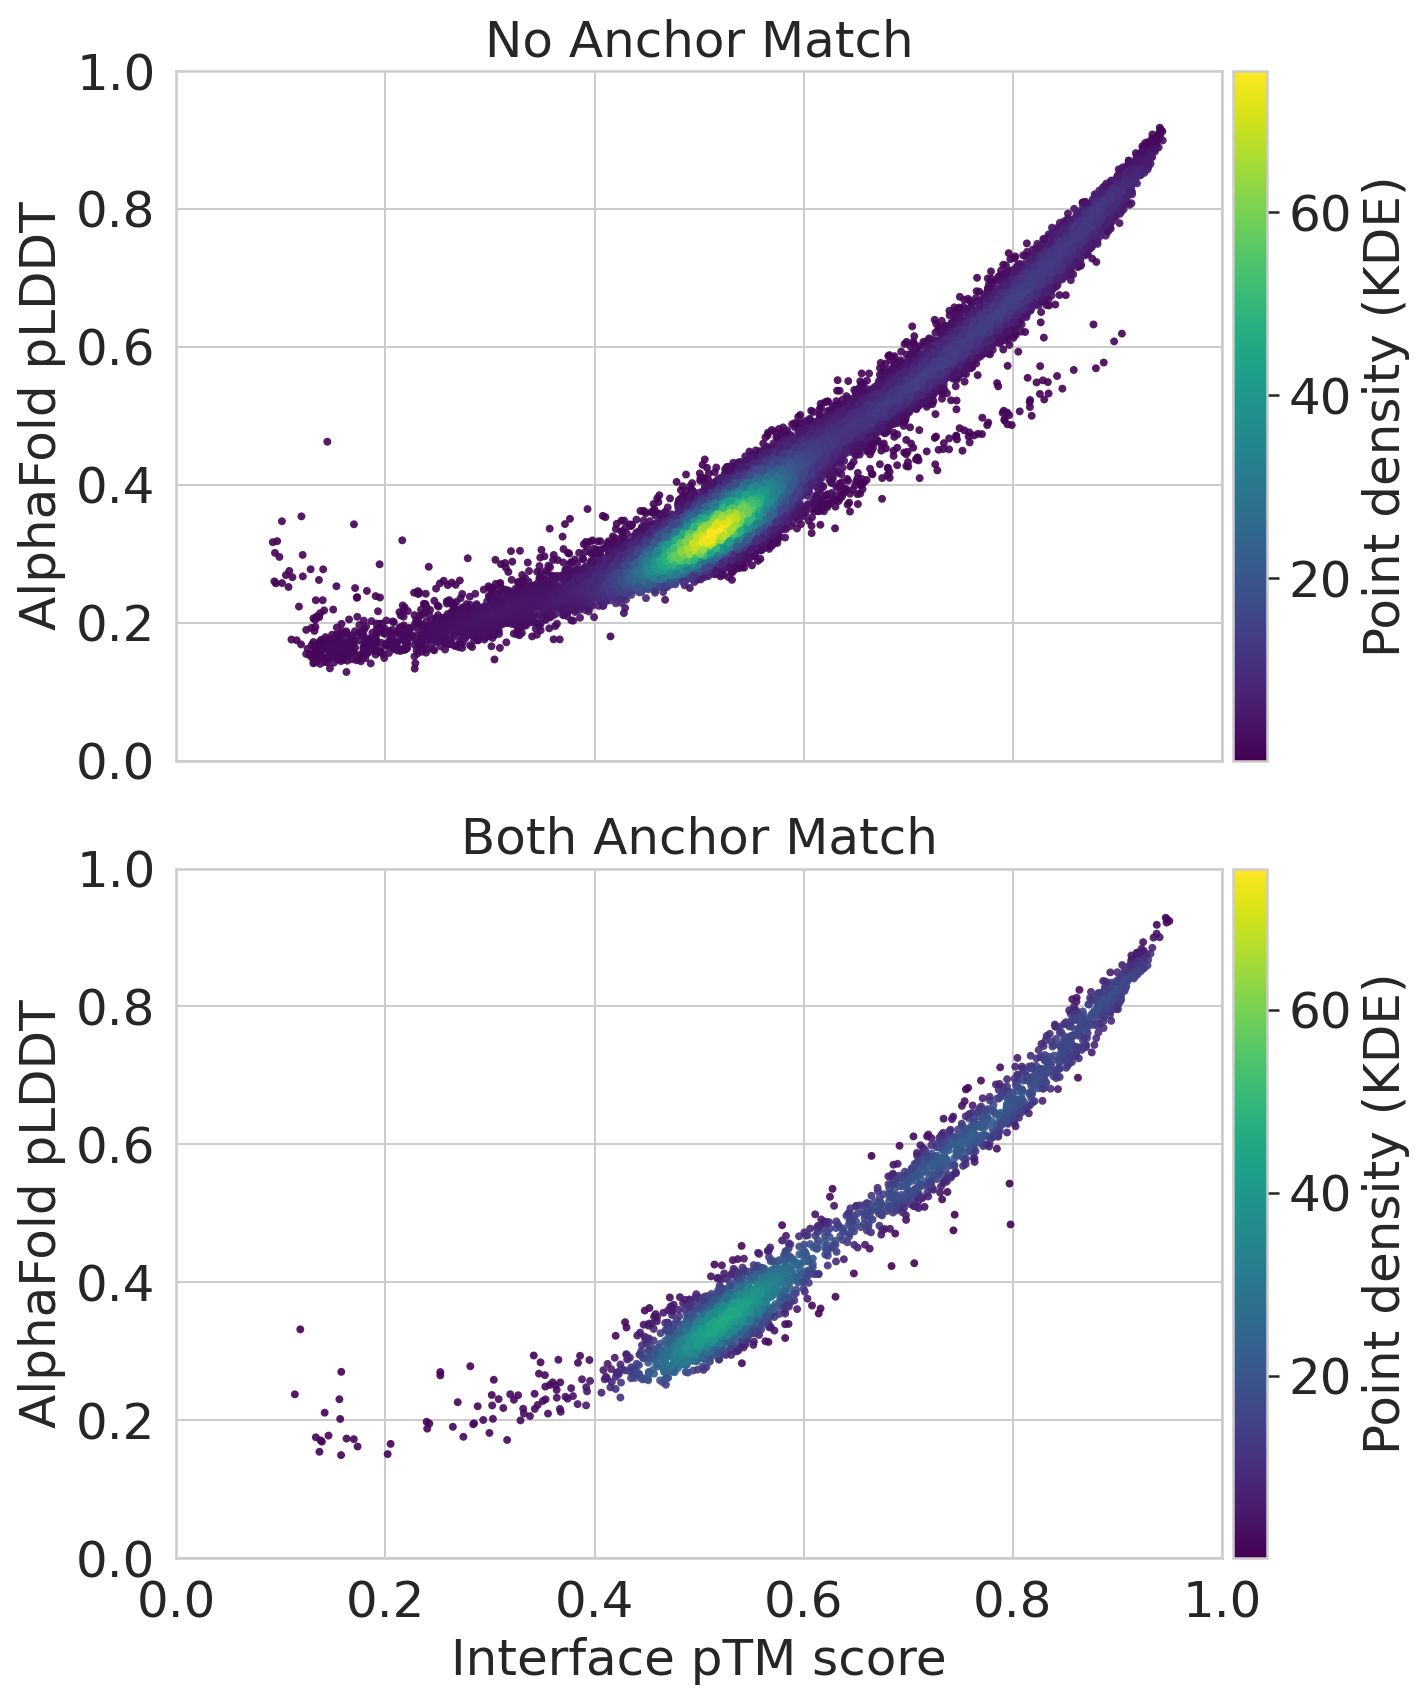

In [53]:
# Example usage:
counts = plot_kde_density(
    results_meta,
    pos2_set={"M", "L", "T"},
    last_set={"V", "L", "T", "A"},
    x_candidates = ['i_ptm'],
    alleles=['A0201', 'A0206', 'A0207'],
    match_types=["both_match"], #both_match last_match either_match pos2_match
    show_grey=False,
    show_window=False,
    thr=0.8,
    suptitle_size=25,
    panel_title_size=20,
    axis_label_size=20,
    tick_label_size=20,
    legend_size=20,
    annotation_size=20
)



In [49]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

In [ ]:
results['hla_allele'] = 'A0201'
counts = plot_kde_density(
    results,
    pos2_set={"M", "L", "T"},
    last_set={"V", "L", "T", "A"},
    x_candidates = ['rmsd'],
    alleles=['A0201'],
    match_types=["both_match"], #both_match last_match
    show_grey=True,
    show_window=True,
    thr=0.8
)

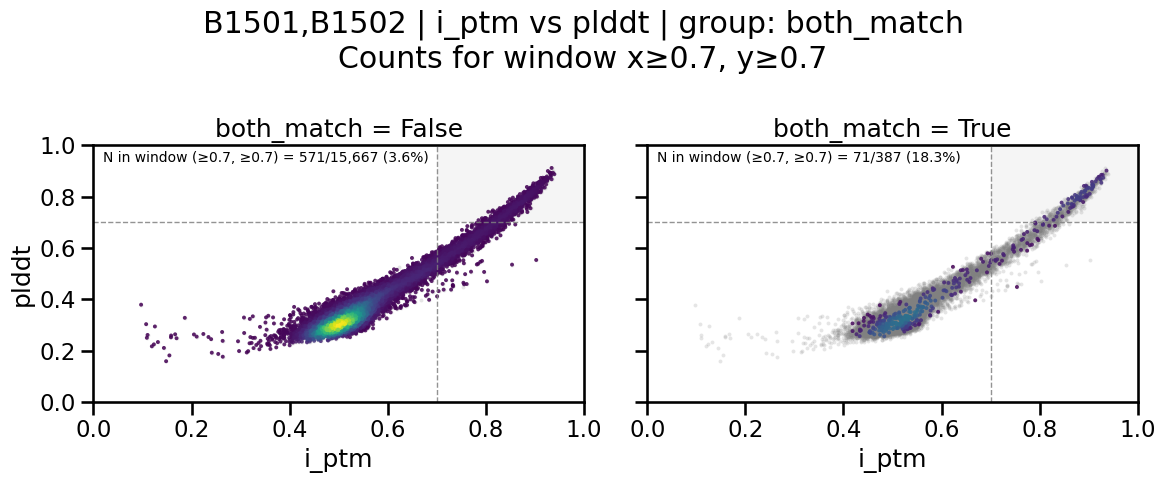

In [ ]:
# Example usage:
counts = plot_kde_density(
    results_meta,
    pos2_set={"M", "L", "T"},
    last_set={"Y", "M", "F"},
    alleles=['B1501', 'B1502'],
    match_types=["both_match"],
    show_grey=True,
    show_window=True,
    thr=0.7
)

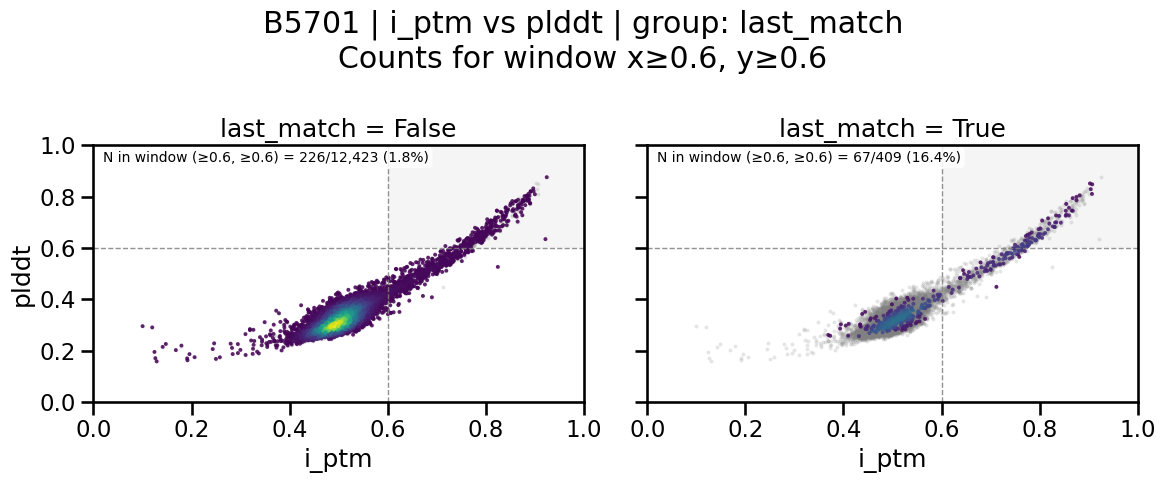

In [ ]:
# Example usage:
counts = plot_kde_density(
    results,
    pos2_set={"A", "S", "T"},
    last_set={"W", "Y", "F"},
    alleles=['B5701'],
    match_types=["last_match"],
    show_grey=True,
    show_window=True,
    thr=0.6
)

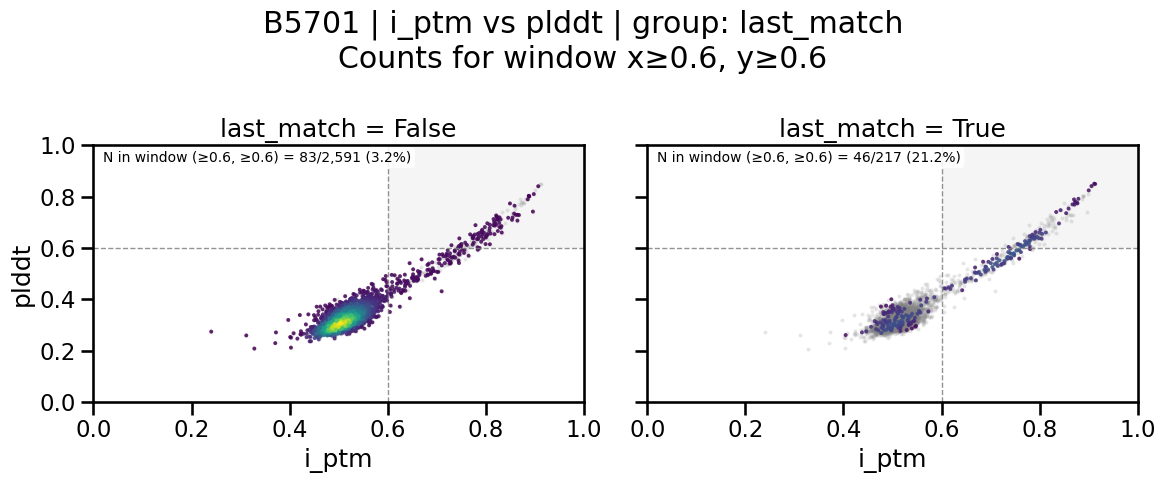

In [ ]:
# Example usage:
counts = plot_kde_density(
    results_meta,
    pos2_set={"A", "S", "T"},
    last_set={"W", "Y", "F"},
    alleles=['B5701'],
    match_types=["last_match"],
    show_grey=True,
    show_window=True,
    thr=0.6
)

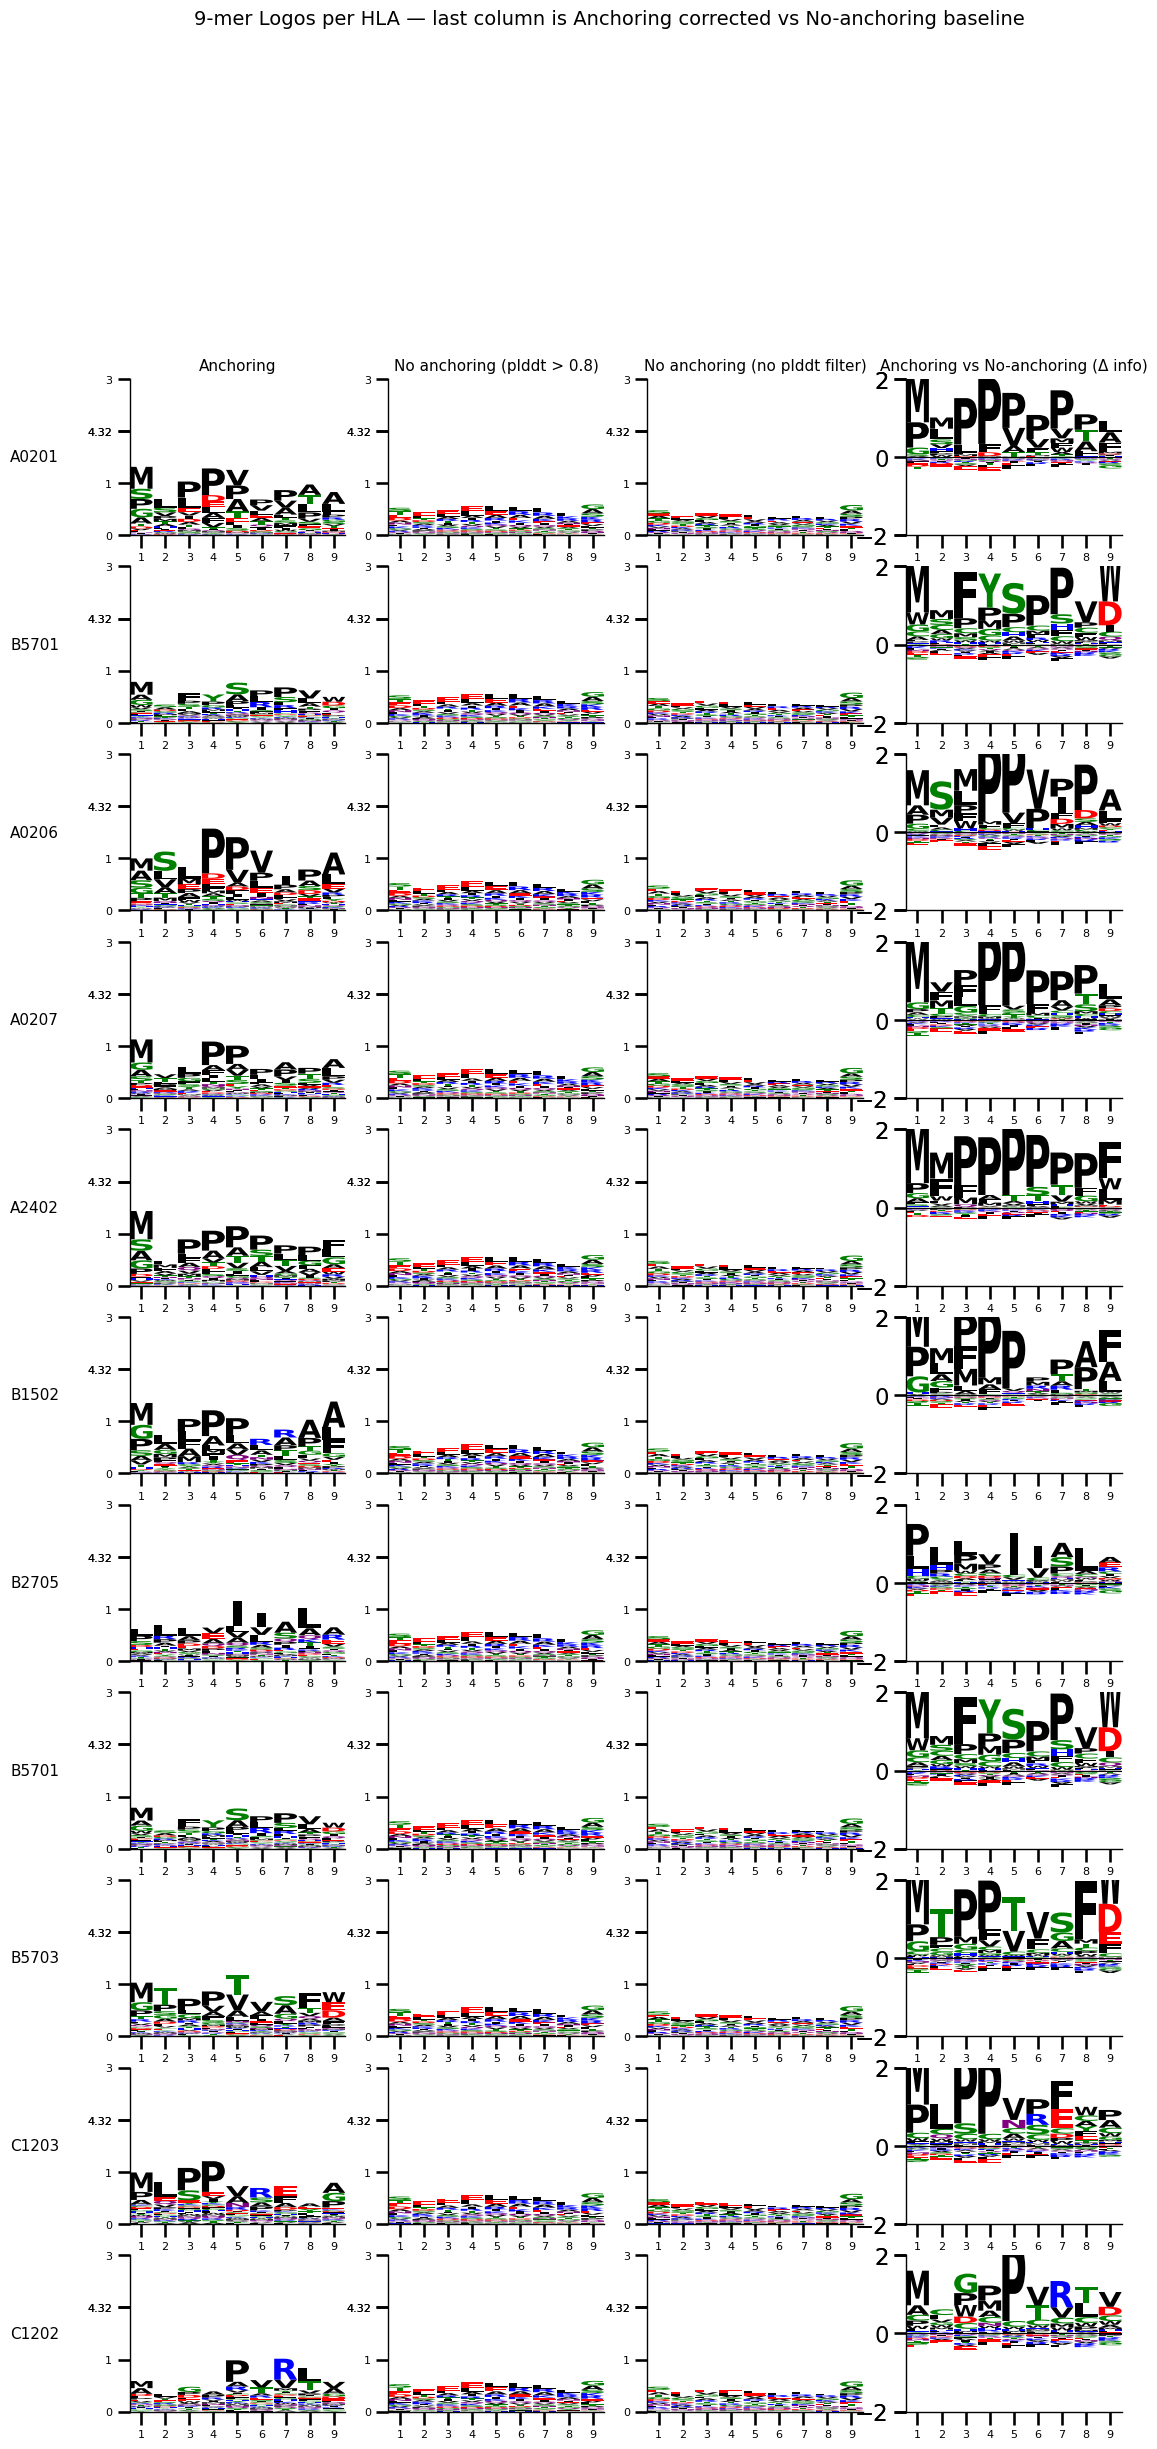

In [ ]:
amino_acids = list("ACDEFGHIKLMNPQRSTVWY")
alleles = ['A0201', 'B5701','A0206','A0207','A2402','B1502','B2705','B5701','B5703','C1203','C1202']
datasets_names = ["Anchoring", "No anchoring (plddt > 0.8)", "No anchoring (no plddt filter)"]

BITS = 2  # 4.321928094...

# =========================
# Helpers
# =========================
def to_df(mat):
    return pd.DataFrame(mat, columns=amino_acids)

def normalize_rows(m, eps=1e-6):
    m = np.asarray(m, dtype=float)
    m = m + eps
    m = m / m.sum(axis=1, keepdims=True)
    return m

def differential_info(p_mat, q_mat, eps=1e-6):
    """
    Return matrix of P(a|pos) * log2(P/Q). p and q are Lx20 probability matrices.
    """
    P = normalize_rows(p_mat, eps)
    Q = normalize_rows(q_mat, eps)
    return P * np.log2(P / Q)

def safe_get_pwm(df, allele):
    """
    build_pwm must return a dict {allele: Lx20 matrix}. We fetch the matrix or None.
    """
    d = build_pwm(df, seq_col="epitope", allele_col="hla_allele")
    return d.get(allele, None)

# =========================
# Figure layout
# =========================
extra_col_name = "Anchoring vs No-anchoring (Δ info)"
plot_columns = datasets_names + [extra_col_name]

n_rows = len(alleles)
n_cols = len(plot_columns)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.2, n_rows * 2.4), squeeze=False)

for row_idx, allele in enumerate(alleles):

    # ---- Build PWMs for this allele ----
    # Anchoring set from results_meta, filter as you prefer (using pLDDT > 0.7 here)
    pwm_pred = safe_get_pwm(
        results_meta[(results_meta['plddt'] > 0.6) & (results_meta['hla_allele'] == allele)],
        allele
    )
    results['hla_allele'] = allele
    # No-anchoring, filtered
    pwm_train = safe_get_pwm(
        results[(results['plddt'] > 0.6) & (results['hla_allele'] == allele)],
        allele
    )
    # No-anchoring, no filter
    pwm_train2 = safe_get_pwm(
        results[(results['plddt'] > 0.0) & (results['hla_allele'] == allele)],
        allele
    )

    datasets = {
        "Anchoring": pwm_pred,
        "No anchoring (plddt > 0.8)": pwm_train,
        "No anchoring (no plddt filter)": pwm_train2
    }

    # If any of the three is missing, blank this row
    if any(datasets[name] is None for name in datasets_names):
        for col_idx in range(n_cols):
            axes[row_idx][col_idx].axis('off')
        continue

    pwm_anchor = datasets["Anchoring"]
    pwm_bg     = datasets["No anchoring (plddt > 0.8)"]

    # ---- Plot three information logos on a 0..4.32 bits scale ----
    for col_idx, name in enumerate(datasets_names):
        ax = axes[row_idx][col_idx]
        pwm = datasets[name]
        freq_df = to_df(pwm)

        # Transform to information content vs uniform background
        info_df = logomaker.transform_matrix(
            freq_df, from_type="probability", to_type="information", background=[1/20]*20
        )
        logo = logomaker.Logo(info_df, ax=ax, color_scheme="chemistry")
        logo.style_spines(visible=False)
        logo.style_spines(spines=['left', 'bottom'], visible=True)

        ax.set_xticks(range(pwm.shape[0]))
        ax.set_xticklabels([str(i + 1) for i in range(pwm.shape[0])], fontsize=8)

        # Fixed y-axis: 0..4.32 bits
        ax.set_ylim(0, BITS)
        ax.set_yticks([0, 1, 2, 3, round(BITS, 2)])
        ax.set_yticklabels(["0", "1", "2", "3", "4.32"], fontsize=8)

        if row_idx == 0:
            ax.set_title(name, fontsize=11, pad=6)
        if col_idx == 0:
            ax.set_ylabel(allele, rotation=0, fontsize=11, labelpad=38, va="center")

    # ---- Differential info logo on a symmetric ±4.32 bits scale ----
    ax = axes[row_idx][len(datasets_names)]
    diff_mat = differential_info(pwm_anchor, pwm_bg, eps=1e-6)  # Lx20, signed
    # Clip for display only, to keep a consistent visual scale
    disp = np.clip(diff_mat, -BITS, BITS)
    diff_df = to_df(disp)

    logo = logomaker.Logo(diff_df, ax=ax, color_scheme="chemistry")
    logo.style_spines(visible=False)
    logo.style_spines(spines=['left', 'bottom'], visible=True)

    ax.axhline(0, linewidth=0.8, color='k')
    ax.set_xticks(range(diff_mat.shape[0]))
    ax.set_xticklabels([str(i + 1) for i in range(diff_mat.shape[0])], fontsize=8)

    ax.set_ylim(-BITS, BITS)
    ax.set_yticks([-round(BITS, 2), -2, 0, 2, round(BITS, 2)])
    # ax.set_yticklabels(["-4.32", "-2", "0", "2", "4.32"], fontsize=8)

    if row_idx == 0:
        ax.set_title(extra_col_name, fontsize=11, pad=6)

plt.suptitle("9-mer Logos per HLA — last column is Anchoring corrected vs No-anchoring baseline", fontsize=14, y=1.02)
# plt.tight_layout(h_pad=0.6, w_pad=0.6)
plt.show()
